# 1m Rolling Johansen OOS Backtest

`Johansen_test_1m`의 실행 결과에서 다음 조건을 만족한 바스켓만 OOS 백테스트합니다.

- Johansen trace test 5%: rank ≥ 1
- Spread ADF p-value < 0.05
- AR(1) mean reversion coefficient `b < 0`
- Half-life: 6시간 이상, 5일 이하

이에 따라 아래 6개 바스켓을 사용합니다.

1. BTC-DOGE-DOT-ETH
2. BTC-AVAX-DOGE-XRP
3. BTC-LINK-SOL-XRP
4. BTC-ETH-LINK-SOL
5. BTC-AVAX-DOGE-ETH
6. BTC-LINK-SOL

백테스트는 **90일 Train → 7일 Test → 7일씩 이동**하는 비중첩 OOS 방식입니다.

중요:
- Johansen weight는 각 Train 구간에서만 다시 추정합니다.
- Test 데이터는 weight 추정에 사용하지 않습니다.
- z-score는 과거 14일 rolling 정보만 사용합니다.
- 각 OOS window 끝에서는 강제 청산합니다.
- 수익률 계산 시 gross exposure를 1로 정규화하여 바스켓별 레버리지 차이를 제거합니다.

In [1]:
!pip install -q statsmodels pyarrow

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.vector_ar.vecm import coint_johansen
from google.colab import drive

drive.mount('/content/drive')

PATH = "/content/drive/MyDrive/코인데이터/ALL_1m.parquet"

df = pd.read_parquet(PATH).sort_index()
df = df.loc["2025-01-01":"2025-12-31"]

print("shape:", df.shape)
print("period:", df.index.min(), "~", df.index.max())
print(df.columns.tolist())

Mounted at /content/drive
shape: (525600, 10)
period: 2025-01-01 00:00:00+00:00 ~ 2025-12-31 23:59:00+00:00
['KRW-ADA', 'KRW-AVAX', 'KRW-BTC', 'KRW-DOGE', 'KRW-DOT', 'KRW-ETH', 'KRW-LINK', 'KRW-SOL', 'KRW-TRX', 'KRW-XRP']


In [3]:
# Johansen_test_1m 실행결과에서 ADF<0.05, b<0, 6h<=half-life<=5d 를 만족한 6개 후보

BASKETS = [
    ["KRW-BTC", "KRW-DOGE", "KRW-DOT", "KRW-ETH"],
    ["KRW-BTC", "KRW-AVAX", "KRW-DOGE", "KRW-XRP"],
    ["KRW-BTC", "KRW-LINK", "KRW-SOL", "KRW-XRP"],
    ["KRW-BTC", "KRW-ETH", "KRW-LINK", "KRW-SOL"],
    ["KRW-BTC", "KRW-AVAX", "KRW-DOGE", "KRW-ETH"],
    ["KRW-BTC", "KRW-LINK", "KRW-SOL"],
]

# 원래 1m screening에서 모든 후보의 VAR p_used=5 → Johansen k_ar_diff=4
K_AR_DIFF = 4

TRAIN_DAYS = 90
TEST_DAYS = 7
STEP_DAYS = 7
ZSCORE_DAYS = 14

ENTRY_Z = 2.0
EXIT_Z = 0.5

DET_ORDER = 0
ALPHA_TRACE = 0.05

BASE_TC_BPS = 5.0
SLIPPAGE_CASES = [0.0, 5.0, 10.0]

# time-based rolling에서 최소 관측치
MIN_Z_OBS = 7 * 24 * 60
MIN_TRAIN_OBS = 60 * 24 * 60

In [4]:
def choose_rank_trace(jres, alpha=0.05):
    col = {0.10: 0, 0.05: 1, 0.01: 2}[alpha]
    rank = 0
    for r in range(len(jres.lr1)):
        if jres.lr1[r] > jres.cvt[r, col]:
            rank = r + 1
    return rank


def johansen_weights_train(logp_train, det_order=0, k_ar_diff=4, alpha=0.05):
    jres = coint_johansen(
        logp_train.values,
        det_order=det_order,
        k_ar_diff=k_ar_diff
    )
    rank = choose_rank_trace(jres, alpha)

    if rank < 1:
        return 0, None

    v = jres.evec[:, 0].astype(float)

    # 첫 자산(BTC) 계수를 1로 정규화
    if abs(v[0]) < 1e-12:
        return 0, None

    w = v / v[0]
    return int(rank), dict(zip(logp_train.columns, w))


def build_spread(logp, weights):
    w = np.array([weights[c] for c in logp.columns], dtype=float)
    return pd.Series(logp.values @ w, index=logp.index)


def rolling_zscore_time(s, days=14):
    # 과거 정보만 사용. 현재 시점까지의 trailing window.
    m = s.rolling(f"{days}D", min_periods=MIN_Z_OBS).mean()
    sd = s.rolling(f"{days}D", min_periods=MIN_Z_OBS).std(ddof=1)
    return (s - m) / (sd + 1e-12)


def gross_normalized_weights(weights):
    # 바스켓마다 Johansen vector 크기가 달라 생기는 레버리지 차이를 제거
    vals = np.array(list(weights.values()), dtype=float)
    gross = np.sum(np.abs(vals))
    if gross <= 1e-12:
        raise ValueError("gross exposure가 0입니다.")
    return {k: v / gross for k, v in weights.items()}


def max_drawdown_from_logret(ret):
    wealth = np.exp(ret.fillna(0.0).cumsum())
    peak = wealth.cummax()
    dd = wealth / peak - 1.0
    return float(dd.min())


def sharpe_from_minute_logret(ret):
    r = ret.dropna()
    if len(r) < 10 or r.std(ddof=1) <= 1e-12:
        return np.nan

    # 1분 수익률을 그대로 연율화하면 microstructure 영향이 너무 커질 수 있으므로
    # 일별 합산 로그수익률로 Sharpe를 계산
    daily = r.resample("1D").sum()
    if len(daily) < 10 or daily.std(ddof=1) <= 1e-12:
        return np.nan

    return float(daily.mean() / daily.std(ddof=1) * np.sqrt(365))


def trade_stats(position, ret):
    position = position.fillna(0).astype(int)
    ret = ret.fillna(0.0)

    trades = []
    in_trade = False
    st = None

    for t, p in position.items():
        if (not in_trade) and p != 0:
            in_trade = True
            st = t
        elif in_trade and p == 0:
            trades.append((st, t))
            in_trade = False
            st = None

    if in_trade and st is not None:
        trades.append((st, position.index[-1]))

    if not trades:
        return {
            "trades": 0,
            "avg_hold_hours": np.nan,
            "win_rate": np.nan,
            "avg_trade_return": np.nan
        }

    trade_returns = []
    hold_hours = []

    for st, ed in trades:
        seg = ret.loc[st:ed]
        trade_returns.append(float(np.expm1(seg.sum())))
        hold_hours.append((ed - st).total_seconds() / 3600)

    return {
        "trades": len(trades),
        "avg_hold_hours": float(np.mean(hold_hours)),
        "win_rate": float(np.mean(np.array(trade_returns) > 0)),
        "avg_trade_return": float(np.mean(trade_returns)),
    }

In [5]:
def backtest_one_basket(df_price, basket, slippage_bps=0.0):
    px_all = df_price[basket].copy()
    px_all = px_all.where(px_all > 0)

    first_valid = px_all.dropna(how="any").index.min()
    last_valid = px_all.dropna(how="any").index.max()

    if pd.isna(first_valid) or pd.isna(last_valid):
        raise ValueError(f"유효 데이터 없음: {basket}")

    # 최소 90일 Train이 확보된 뒤부터 Test 시작
    test_start = first_valid + pd.Timedelta(days=TRAIN_DAYS)
    last_test_start = last_valid - pd.Timedelta(days=TEST_DAYS)

    all_rows = []
    window_rows = []

    while test_start <= last_test_start:
        train_start = test_start - pd.Timedelta(days=TRAIN_DAYS)
        test_end = test_start + pd.Timedelta(days=TEST_DAYS)

        train_px = px_all.loc[train_start:test_start].iloc[:-1].dropna(how="any")
        test_px = px_all.loc[test_start:test_end].iloc[:-1].dropna(how="any")

        if len(train_px) < MIN_TRAIN_OBS or len(test_px) < 1000:
            window_rows.append({
                "test_start": test_start,
                "test_end": test_end,
                "rank_95": np.nan,
                "status": "insufficient_data"
            })
            test_start += pd.Timedelta(days=STEP_DAYS)
            continue

        train_logp = np.log(train_px)

        try:
            rank, coint_weights = johansen_weights_train(
                train_logp,
                det_order=DET_ORDER,
                k_ar_diff=K_AR_DIFF,
                alpha=ALPHA_TRACE
            )
        except Exception as e:
            window_rows.append({
                "test_start": test_start,
                "test_end": test_end,
                "rank_95": np.nan,
                "status": f"johansen_error: {type(e).__name__}"
            })
            test_start += pd.Timedelta(days=STEP_DAYS)
            continue

        window_rows.append({
            "test_start": test_start,
            "test_end": test_end,
            "rank_95": rank,
            "status": "tradable" if rank >= 1 else "rank0",
            "weights": coint_weights
        })

        # 공적분 관계가 없으면 그 OOS 구간은 거래하지 않음
        if rank < 1 or coint_weights is None:
            for t in test_px.index:
                all_rows.append({
                    "time": t, "pos": 0, "z": np.nan,
                    "gross_ret": 0.0, "cost": 0.0, "net_ret": 0.0,
                    "rank_95": 0
                })
            test_start += pd.Timedelta(days=STEP_DAYS)
            continue

        # z-score 계산을 위해 Train + Test를 이어 붙임
        combined_px = pd.concat([train_px, test_px]).sort_index()
        combined_px = combined_px[~combined_px.index.duplicated(keep="last")]
        combined_logp = np.log(combined_px)

        spread = build_spread(combined_logp, coint_weights)
        z = rolling_zscore_time(spread, ZSCORE_DAYS)

        # 거래 PnL용 weight는 gross=1로 정규화
        trade_w = gross_normalized_weights(coint_weights)
        w_vec = np.array([trade_w[c] for c in basket], dtype=float)

        test_logp = combined_logp.loc[test_px.index]
        asset_lr = test_logp.diff()

        # 첫 Test bar의 수익률에는 직전 Train bar가 필요
        prev_idx = combined_logp.index.get_indexer([test_px.index[0]])[0] - 1
        if prev_idx >= 0:
            prev_logp = combined_logp.iloc[prev_idx]
            asset_lr.iloc[0] = test_logp.iloc[0] - prev_logp

        pos = 0
        prev_trade_weights = np.zeros(len(basket), dtype=float)

        fee_rate = (BASE_TC_BPS + slippage_bps) / 10000.0

        test_rows = []

        for t in test_px.index:
            zt = z.loc[t] if t in z.index else np.nan

            new_pos = pos

            if np.isfinite(zt):
                if pos == 0:
                    if zt >= ENTRY_Z:
                        new_pos = -1
                    elif zt <= -ENTRY_Z:
                        new_pos = 1
                elif pos == 1 and zt >= -EXIT_Z:
                    new_pos = 0
                elif pos == -1 and zt <= EXIT_Z:
                    new_pos = 0

            current_trade_weights = new_pos * w_vec

            turnover = float(np.sum(np.abs(current_trade_weights - prev_trade_weights)))
            cost = turnover * fee_rate

            lr = asset_lr.loc[t].values.astype(float)
            if np.any(~np.isfinite(lr)):
                gross_ret = 0.0
            else:
                # 직전 보유 weight로 해당 bar 수익 발생
                gross_ret = float(prev_trade_weights @ lr)

            net_ret = gross_ret - cost

            test_rows.append({
                "time": t,
                "pos": int(new_pos),
                "z": float(zt) if np.isfinite(zt) else np.nan,
                "gross_ret": gross_ret,
                "cost": cost,
                "net_ret": net_ret,
                "rank_95": int(rank)
            })

            pos = new_pos
            prev_trade_weights = current_trade_weights

        # OOS window 끝에서 강제청산 + 청산비용 반영
        if test_rows and pos != 0:
            close_turnover = float(np.sum(np.abs(prev_trade_weights)))
            close_cost = close_turnover * fee_rate
            test_rows[-1]["cost"] += close_cost
            test_rows[-1]["net_ret"] -= close_cost
            test_rows[-1]["pos"] = 0

        all_rows.extend(test_rows)
        test_start += pd.Timedelta(days=STEP_DAYS)

    result = pd.DataFrame(all_rows)
    windows = pd.DataFrame(window_rows)

    if result.empty:
        return result, windows, {}

    result = result.sort_values("time").set_index("time")
    result = result[~result.index.duplicated(keep="last")]

    cumulative_return = float(np.expm1(result["net_ret"].sum()))
    sharpe = sharpe_from_minute_logret(result["net_ret"])
    mdd = max_drawdown_from_logret(result["net_ret"])

    ts = trade_stats(result["pos"], result["net_ret"])

    n_windows = len(windows)
    n_coint = int((windows["rank_95"] >= 1).sum()) if n_windows else 0

    summary = {
        "basket": "|".join(basket),
        "slippage_bps": slippage_bps,
        "oos_windows": n_windows,
        "rank_ge_1_windows": n_coint,
        "cointegration_window_ratio": n_coint / n_windows if n_windows else np.nan,
        "cumulative_return": cumulative_return,
        "sharpe": sharpe,
        "mdd": mdd,
        **ts
    }

    return result, windows, summary

In [6]:
all_summaries = []
all_results = {}
all_windows = {}

for basket in BASKETS:
    basket_key = "|".join(basket)

    for slip in SLIPPAGE_CASES:
        print(f"Running: {basket_key}, slippage={slip}bps")

        result, windows, summary = backtest_one_basket(
            df,
            basket,
            slippage_bps=slip
        )

        all_results[(basket_key, slip)] = result
        all_windows[(basket_key, slip)] = windows
        all_summaries.append(summary)

summary_df = pd.DataFrame(all_summaries)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

print("\n=== SUMMARY ===")
print(summary_df.to_string(index=False))

Running: KRW-BTC|KRW-DOGE|KRW-DOT|KRW-ETH, slippage=0.0bps
Running: KRW-BTC|KRW-DOGE|KRW-DOT|KRW-ETH, slippage=5.0bps
Running: KRW-BTC|KRW-DOGE|KRW-DOT|KRW-ETH, slippage=10.0bps
Running: KRW-BTC|KRW-AVAX|KRW-DOGE|KRW-XRP, slippage=0.0bps
Running: KRW-BTC|KRW-AVAX|KRW-DOGE|KRW-XRP, slippage=5.0bps
Running: KRW-BTC|KRW-AVAX|KRW-DOGE|KRW-XRP, slippage=10.0bps
Running: KRW-BTC|KRW-LINK|KRW-SOL|KRW-XRP, slippage=0.0bps
Running: KRW-BTC|KRW-LINK|KRW-SOL|KRW-XRP, slippage=5.0bps
Running: KRW-BTC|KRW-LINK|KRW-SOL|KRW-XRP, slippage=10.0bps
Running: KRW-BTC|KRW-ETH|KRW-LINK|KRW-SOL, slippage=0.0bps
Running: KRW-BTC|KRW-ETH|KRW-LINK|KRW-SOL, slippage=5.0bps
Running: KRW-BTC|KRW-ETH|KRW-LINK|KRW-SOL, slippage=10.0bps
Running: KRW-BTC|KRW-AVAX|KRW-DOGE|KRW-ETH, slippage=0.0bps
Running: KRW-BTC|KRW-AVAX|KRW-DOGE|KRW-ETH, slippage=5.0bps
Running: KRW-BTC|KRW-AVAX|KRW-DOGE|KRW-ETH, slippage=10.0bps
Running: KRW-BTC|KRW-LINK|KRW-SOL, slippage=0.0bps
Running: KRW-BTC|KRW-LINK|KRW-SOL, slippage=5.0bps
Ru

In [7]:
# 결과 저장

summary_df.to_csv(
    "1m_backtest_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

for (basket_key, slip), result in all_results.items():
    safe = basket_key.replace("KRW-", "").replace("|", "_")
    result.to_csv(
        f"1m_detail_{safe}_slip{int(slip)}bps.csv",
        encoding="utf-8-sig"
    )

for (basket_key, slip), windows in all_windows.items():
    safe = basket_key.replace("KRW-", "").replace("|", "_")
    windows.to_csv(
        f"1m_windows_{safe}_slip{int(slip)}bps.csv",
        index=False,
        encoding="utf-8-sig"
    )

print("Saved: 1m_backtest_summary.csv + detail/window CSV files")

Saved: 1m_backtest_summary.csv + detail/window CSV files


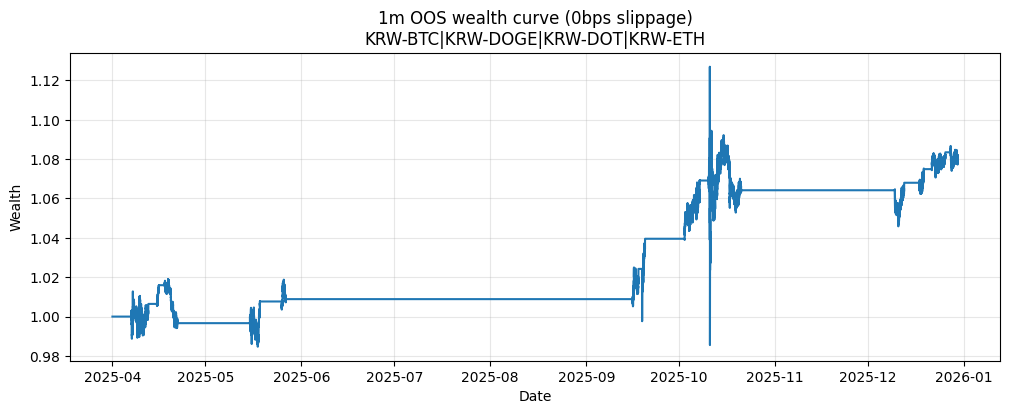

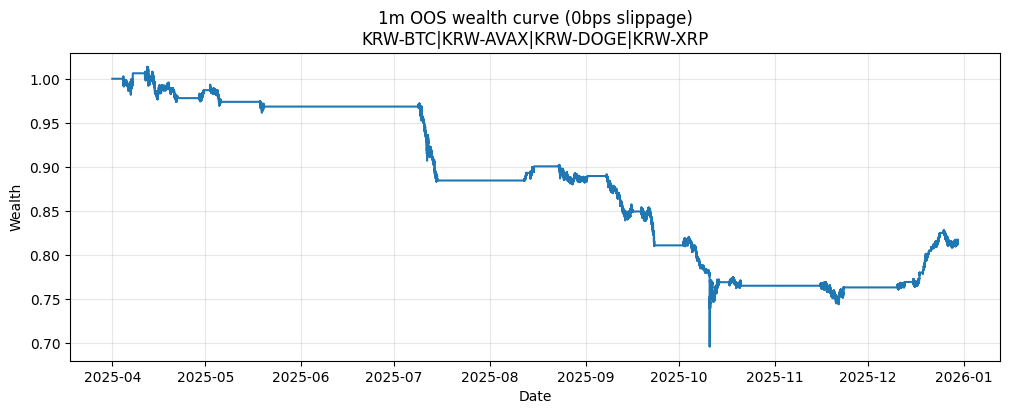

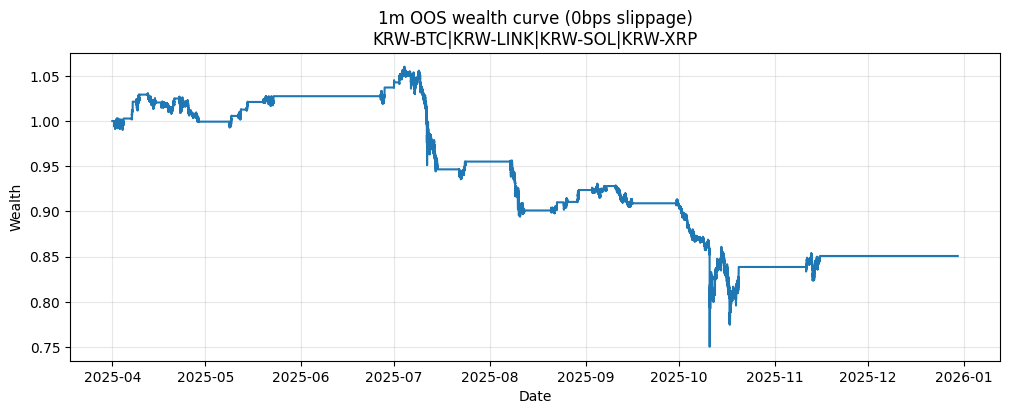

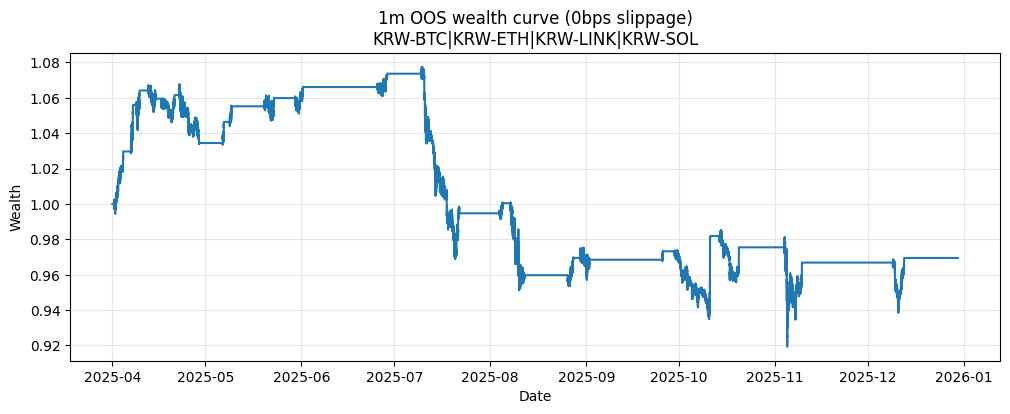

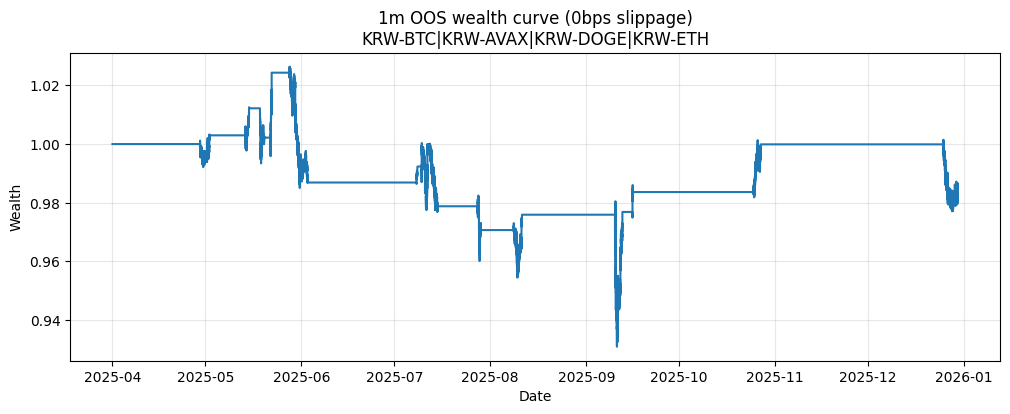

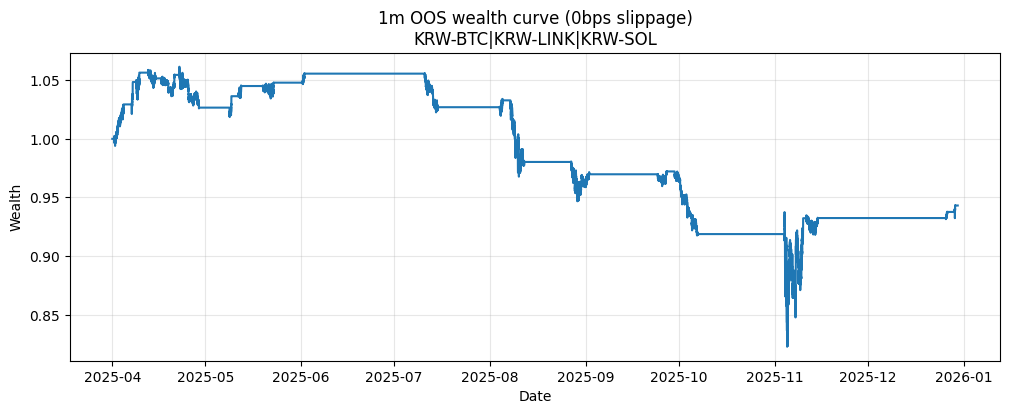

In [8]:
# 0bps 기준 누적성과 그래프

for basket in BASKETS:
    basket_key = "|".join(basket)
    result = all_results[(basket_key, 0.0)]

    if result.empty:
        continue

    wealth = np.exp(result["net_ret"].cumsum())

    plt.figure(figsize=(12, 4))
    plt.plot(wealth.index, wealth.values)
    plt.title(f"1m OOS wealth curve (0bps slippage)\n{basket_key}")
    plt.xlabel("Date")
    plt.ylabel("Wealth")
    plt.grid(True, alpha=0.3)
    plt.show()